# <b><font color='coral'>Исследование данных с помощью визуализации </font></b>

[RegExp](https://habr.com/ru/articles/545150/)

In [22]:
# Для Алексея
import pandas as pd
import numpy as np

data = {
    "Name": ["Alice", "Alice", "Bob", "Bob", "Charlie", "Charlie", "David", "Eve", "Eve", "Frank"],
    "Department": ["HR", np.nan, "IT", "Finance", np.nan, "Marketing", "Sales", "IT", np.nan, "HR"],
    "Date": ["2024-01-01", "2024-03-01","2024-02-01", "2024-04-01", "2024-01-15", "2024-02-20","2024-03-10","2024-01-05", "2024-02-10", "2024-03-15"
    ]
}
df = pd.DataFrame(data)
df["Date"] = pd.to_datetime(df["Date"])
df

,Name,Department,Date
0,Alice,HR,2024-01-01
1,Alice,NaN,2024-03-01
2,Bob,IT,2024-02-01
3,Bob,Finance,2024-04-01
4,Charlie,NaN,2024-01-15
5,Charlie,Marketing,2024-02-20
6,David,Sales,2024-03-10
7,Eve,IT,2024-01-05
8,Eve,NaN,2024-02-10
9,Frank,HR,2024-03-15


In [23]:
df_sorted = df.sort_values(["Name", "Date"], ascending=[True, False])

# помечаем валидные строки
df_sorted["valid"] = df_sorted["Department"].notna()
display(df_sorted)
# берем первую валидную строку в каждой группе
result = df_sorted[df_sorted["valid"]].drop_duplicates("Name")

result.drop(columns="valid")

,Name,Department,Date,valid
1,Alice,NaN,2024-03-01,False
0,Alice,HR,2024-01-01,True
3,Bob,Finance,2024-04-01,True
2,Bob,IT,2024-02-01,True
5,Charlie,Marketing,2024-02-20,True
4,Charlie,NaN,2024-01-15,False
6,David,Sales,2024-03-10,True
8,Eve,NaN,2024-02-10,False
7,Eve,IT,2024-01-05,True
9,Frank,HR,2024-03-15,True


,Name,Department,Date
0,Alice,HR,2024-01-01
3,Bob,Finance,2024-04-01
5,Charlie,Marketing,2024-02-20
6,David,Sales,2024-03-10
7,Eve,IT,2024-01-05
9,Frank,HR,2024-03-15


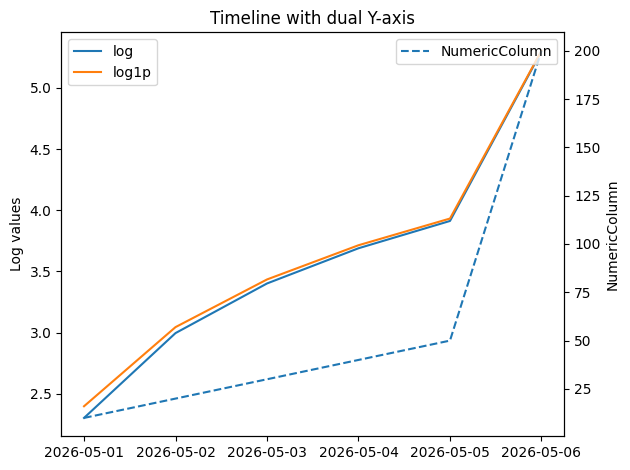

In [24]:
import matplotlib.pyplot as plt
# Масштабирование данных
df = pd.DataFrame({
    'NumericColumn': [10, 20, 30, 40, 50, 200],
    'NumericColumn1': [1, 2, 3, 4, 5, 100],
    'NumericColumn2': [0.1, 0.2, 0.3, 0.4, 0.5, 10]
})

# вычисляем логарифмы
df["log"] = np.log(df["NumericColumn"])
df["log1p"] = np.log1p(df["NumericColumn"])

# Добавим даты в качестве индексов
dates = pd.date_range(start="2026-05-01", periods=len(df), freq="D")
df.index = dates

# Нарисуем timiline
fig, ax1 = plt.subplots()

# левая ось — для логарифмов
ax1.plot(df.index, df["log"], label="log")
ax1.plot(df.index, df["log1p"], label="log1p")
ax1.set_ylabel("Log values")
ax1.legend(loc="upper left")

# правая ось — для исходных значений
ax2 = ax1.twinx()
ax2.plot(df.index, df["NumericColumn"], linestyle="--", label="NumericColumn")
ax2.set_ylabel("NumericColumn")

ax2.legend(loc="upper right")

plt.title("Timeline with dual Y-axis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### <font color='coral'>1.  Описание набора данных Wine Recognition</font>

Слайды 5-14 презентации

- <i>alcohol</i> - содержание алкоголя. Показывает, сколько миллилитров чистого этанола содержится в 100 мл вина.
- <i>malic_acid</i> - содержание молочной кислоты (г/л)
- <i>ash</i> - содержание золы, осатка минеральных веществ после термического сжигания вина (г/л)
- <i>alcalinity_of_ash</i> - щёлочность золы. Характеризует щёлочной состав минеральных веществ (мг/л)
- <i>magnesium</i> - содержание магния (мг/л)
- <i>total_phenols</i> - содержание фенолов (г/л)
- <i>flavanoids</i> - содержание флавоноидов, одного из подклассов фенолов (г/л)
- <i>nonflavanoid_phenols</i> - содержание нефлавоноидных фенолов (г/л)
- <i>proanthocyanins</i> - содержание проантоцианидинов, одного из типов танинов (г/л)
- <i>color_intensity</i> - интенсивность цвета. Измеряется в единицах абсорбации (измеряется спектрофотометром)
- <i>hue</i> - оттенок. Отношение OD420 к OD500 (оптической плотности вина при длине волны 420 нм к оптической плотности вина при длине волны 500 нм). OD420 - жёлто-оранжевый свет, OD500 - зелёный свет.
- <i>od280/od315_of_diluted_wines</i> - Отношение OD280 к OD315 (оптической плотности вина при длине волны 280 нм к оптической плотности вина при длине волны 315 нм). OD280 - поглощают фенольные соединения с ароматическими кольцами (флавоноиды, танины), OD315 - поглощают другие фенольные соединения.
- <i>proline</i> - содержание аминокислоты - пролина (мг/л)

### <font color='coral'>2. Установка необходимых библиотек</font>

In [25]:
# Импорт бибилиотек
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine, load_iris
import matplotlib.pyplot as plt
import seaborn as sns

[sklearn_datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html)

### <font color='coral'>3. Загрузка данных</font>

In [26]:
# Что хранится внутри load_wine()
load_wine()

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [27]:
# Запись данных в DataFrame
# Способ №1
df_wine_1 = pd.DataFrame(load_wine().data, columns=load_wine().feature_names)
df_wine_1["class"] = load_wine().target
df_wine_1.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [28]:
# Способ №2
# return_X_y = True указывает, что функция должна вернуть матрицу признаков (X) и целевую переменную (y)
# as_frame = True указывает, что данные должны быть возвращены в виде pandas DataFrame (X) и Series (y) соответственно.
df_wine_2, y = load_wine(return_X_y = True, as_frame = True)
df_wine_2['class'] = y
df_wine_2.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### <font color='coral'>4. Описание данных</font>

In [29]:
# Изучим датафрейм
print(load_wine().DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

### <font color='coral'>5. Распределение классов</font>

class
0    59
1    71
2    48
Name: count_class, dtype: int64

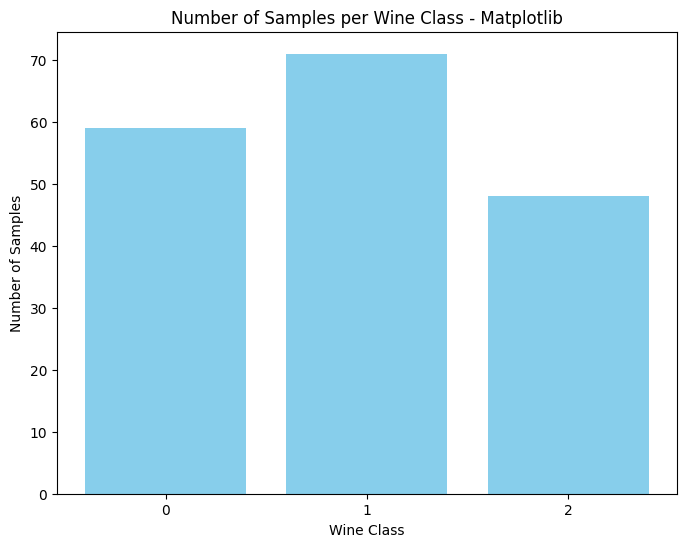

In [42]:
# Нарисуйте столбчатую диаграмму, показывающую количество образцов вина для каждого класса
# Способ №1 - с помощью matplotlib
# 1. Сгруппируйте данные по классу для подсчета количества образцов 
# и переименуйте колонку с подсчитанными значениями как count_class
# В результате у Вас получится объект типа Series, где индексом будет название класса
# а в столбце - подсчитанные значения.
# Сохраните получившийся объект в переменную class_counts
#------------
class_counts = df_wine_1.groupby("class").size().rename("count_class")
display(class_counts)
#-----------
# 2. Создайте объект "фигура" с размерами (8, 6)
#------------
plt.figure(figsize=(8, 6))
#-----------
# 3. Нарисуйте столбчатую диаграмму, где по оси X будут названия классов, а по оси Y - количество значений для каждого класса
# Задайте цвет баров - 'skyblue'
#------------
plt.bar(class_counts.index, class_counts.values, color='skyblue')
#-----------
# 4. С помощью функции xticks() подпишите ось X таким образом, чтобы под каждым столбцом было название класса
#------------
plt.xticks(class_counts.index)
#-----------
# 5. Подпишите ось X как "Wine Class"
#------------
plt.xlabel("Wine Class")
#-----------
# 6. Подпишите ось Y как "Number of Samples"
#------------
plt.ylabel("Number of Samples")
#-----------
# 7. Подпишите получившуюся столбчатую диаграмму как "Number of Samples per Wine Class - Matplotlib"
#------------
plt.title("Number of Samples per Wine Class - Matplotlib")
#-----------
plt.show()

class
0    59
1    71
2    48
Name: count_class, dtype: int64

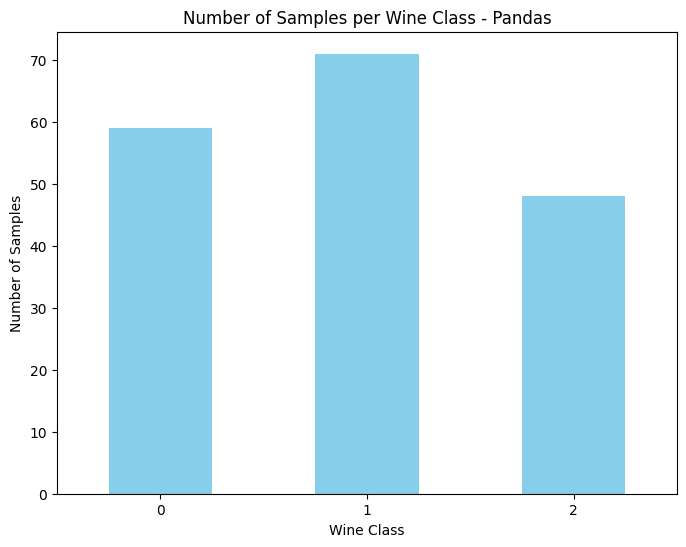

In [46]:
# Нарисуйте столбчатую диаграмму, показывающую количество образцов вина для каждого класса
# Способ №2 - с помощью pandas
# 1. Сгруппируйте данные по классу для подсчета количества образцов 
# и переименуйте колонку с подсчитанными значениями как count_class
# В результате у Вас получится объект типа Series, где индексом будет название класса
# а в столбце - подсчитанные значения.
# Сохраните получившийся объект в переменную class_counts
#------------
class_counts = df_wine_1.groupby("class").size().rename("count_class")
display(class_counts)
#-----------
# 2. Создайте объект "фигура" с размерами (8, 6)
#------------
plt.figure(figsize=(8, 6))
#-----------
# 3. Нарисуйте столбчатую диаграмму (в параметрах сразу задайте название диаграммы "Number of Samples per Wine Class - Pandas")
# Задайте цвет баров - 'skyblue'
#------------
class_counts.plot(kind='bar', color='skyblue', title="Number of Samples per Wine Class - Pandas")
#-----------
# 4. С помощью функции xticks() и атрибута rotation отобразите подписи оси X в вертикальном положении
#------------
plt.xticks(rotation=0)
#-----------
# 5. Подпишите ось X как "Wine Class"
#------------
plt.xlabel("Wine Class")
#-----------
# 6. Подпишите ось Y как "Number of Samples"
#------------
plt.ylabel("Number of Samples")
#-----------
plt.show()

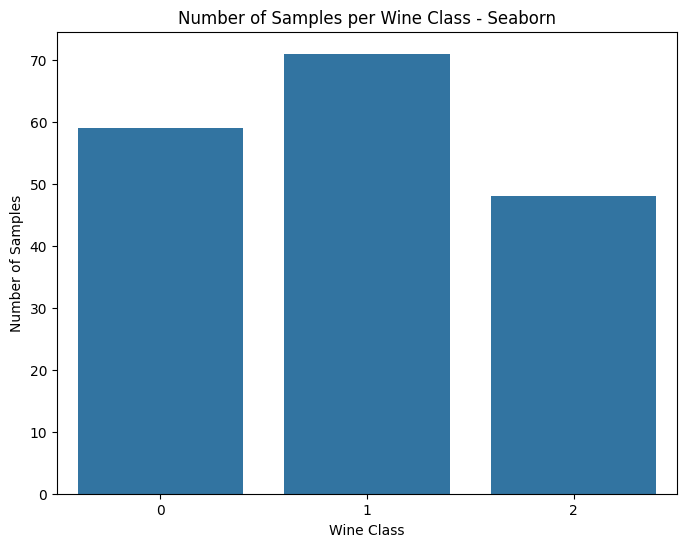

In [51]:
# Нарисуйте столбчатую диаграмму, показывающую количество образцов вина для каждого класса
# Способ №3 - с помощью seaborn
# 1. Создайте объект "фигура" с размерами (8, 6)
#------------
plt.figure(figsize=(8, 6))
#-----------
# 2. Нарисуйте столбчатую диаграмму countplot (по оси X - class, data = датафрейм df_wine_1)
#------------
sns.countplot(x='class', data=df_wine_1)
#-----------
# 3. Подпишите ось X как "Wine Class"
#------------
plt.xlabel("Wine Class")
#-----------
# 4. Подпишите ось Y как "Number of Samples"
#------------
plt.ylabel("Number of Samples")
#-----------
# 5. Подпишите получившуюся столбчатую диаграмму как "Number of Samples per Wine Class - Seaborn"
#------------
plt.title("Number of Samples per Wine Class - Seaborn")
#-----------
plt.show()

### <font color='coral'>6. Boxplot</font>

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


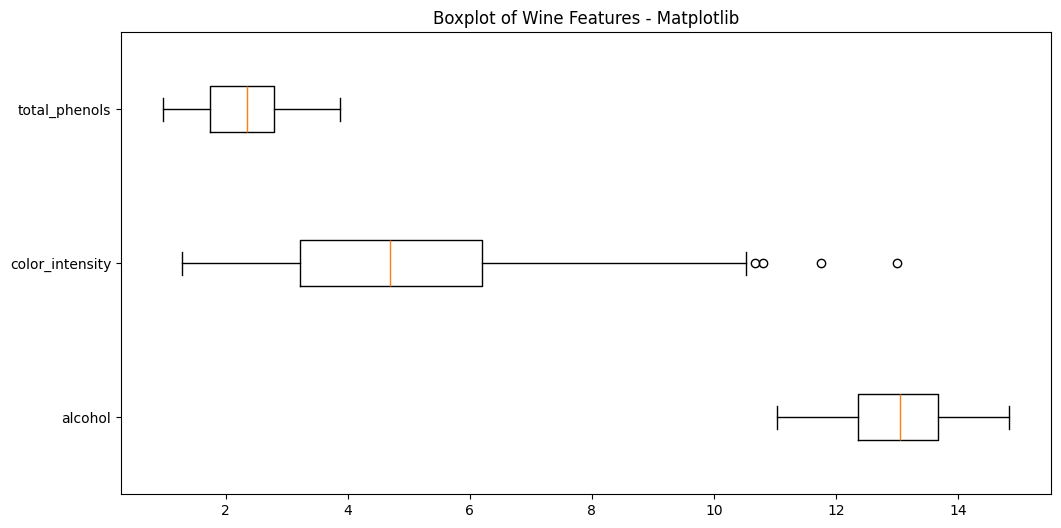

In [67]:
# Постройте boxplot с помощью библиотеки matplotlib
# 1) для всех столбцов
# 1. Создайте объект "фигура" с размерами (12, 6)
display(df_wine_2.head())
#------------
plt.figure(figsize=(12, 6))
#-----------
# 2. Постройте boxplot c параметрами: x = df_wine_1.values, labels = df_wine_1.columns, orientation = 'horizontal' 
#------------
plt.boxplot(x=df_wine_1[['alcohol','color_intensity', 'total_phenols']], tick_labels=df_wine_1[['alcohol','color_intensity', 'total_phenols']].columns, vert=False)

#-----------
# 3. Подпишите получившийся boxplot как "Boxplot of Wine Features - Matplotlib"
#------------
plt.title("Boxplot of Wine Features - Matplotlib")
#-----------
plt.show()

In [ ]:
# Постройте boxplot с помощью библиотеки matplotlib
# 2) для столбцов, имеющих выбросы
# 1. В отдельный датафрейм df_wine_1_anomalies выделите столбцы, которые имеют выбросы
#------------
df_wine_1_anomalies = df_wine_1[['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']]
#-----------
# 2. Создайте объект "фигура" с размерами (6, 3)
#------------
plt.figure(figsize=(6, 3))
#-----------
# 3. Постройте boxplot c параметрами: x = df_wine_1_anomalies.values, labels = df_wine_1_anomalies.columns, orientation = 'horizontal' 
#------------
plt.boxplot(x=df_wine_1_anomalies.values, labels=df_wine_1_anomalies.columns, vert=False)
#-----------
# 4. Подпишите получившийся boxplot как "Boxplot of Wine Features - Matplotlib"
#------------
plt.title("Boxplot of Wine Features - Matplotlib")
#-----------
plt.show()

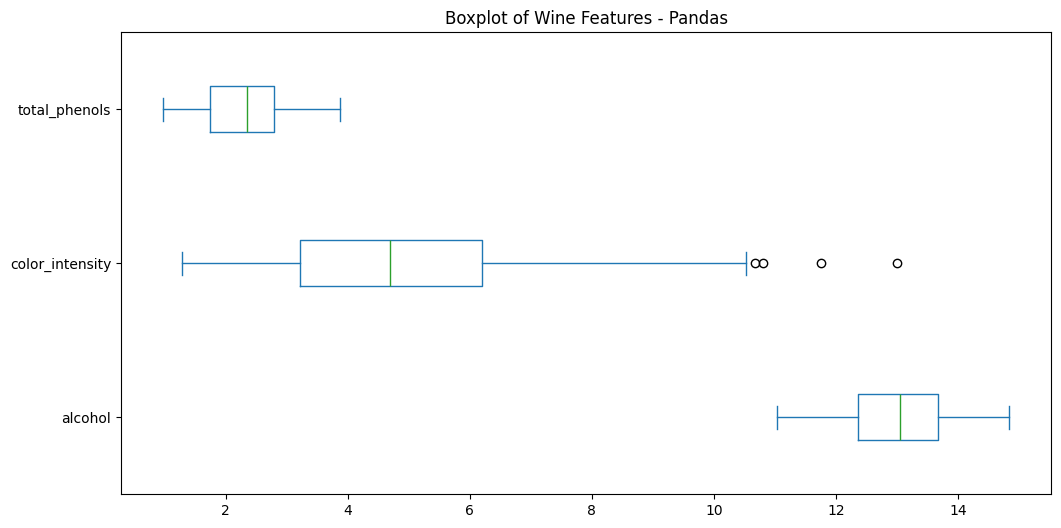

In [70]:
# Постройте boxplot с помощью библиотеки pandas для столбцов, имеющих выбросы
# Используйте датафрейм df_wine_1_anomalies
# 1. Постройте boxplot c параметрами figsize = (12, 6), rot = 90, title = 'Boxplot of Wine Features - Pandas'

#------------
df_wine_1[['alcohol','color_intensity', 'total_phenols']].plot(kind='box', figsize=(12, 6), rot=0, title='Boxplot of Wine Features - Pandas', vert=False)
#-----------
plt.show()

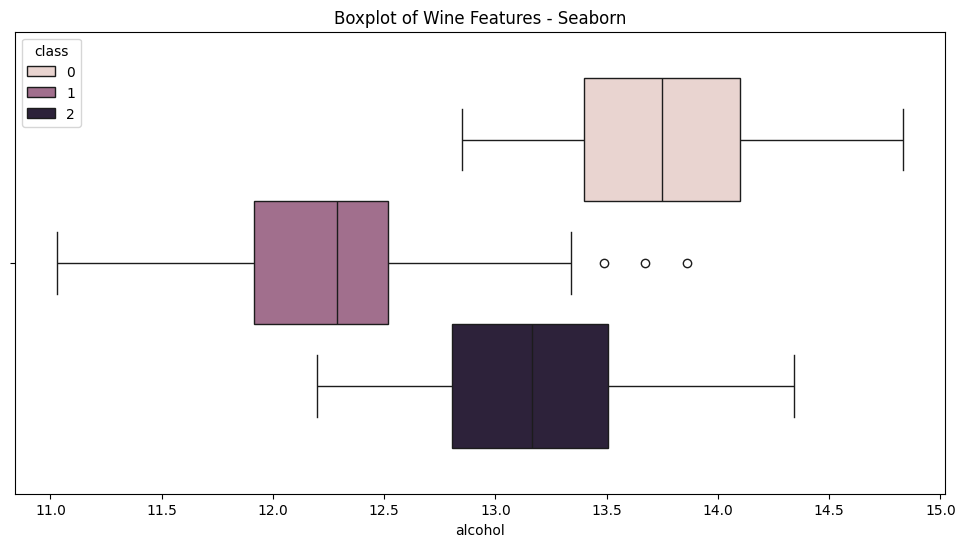

In [79]:
# Постройте boxplot с помощью библиотеки seaborn для столбцов, имеющих выбросы
# Используйте датафрейм df_wine_1_anomalies
# 1. Создайте объект "фигура" с размерами (12, 6)
#------------
plt.figure(figsize=(12, 6))
#-----------
# 2. Постройте boxplot c одним параметром data = df_wine_1_anomalies
#------------
sns.boxplot(data=df_wine_1[['alcohol','color_intensity', 'total_phenols', 'class']], x = 'alcohol', orient='h', hue='class')
#-----------
# 3. Подпишите получившийся boxplot как "Boxplot of Wine Features - Seaborn"
#------------
plt.title("Boxplot of Wine Features - Seaborn")
#-----------
plt.show()

### <font color='coral'>7. Корреляция и тепловая карта</font>

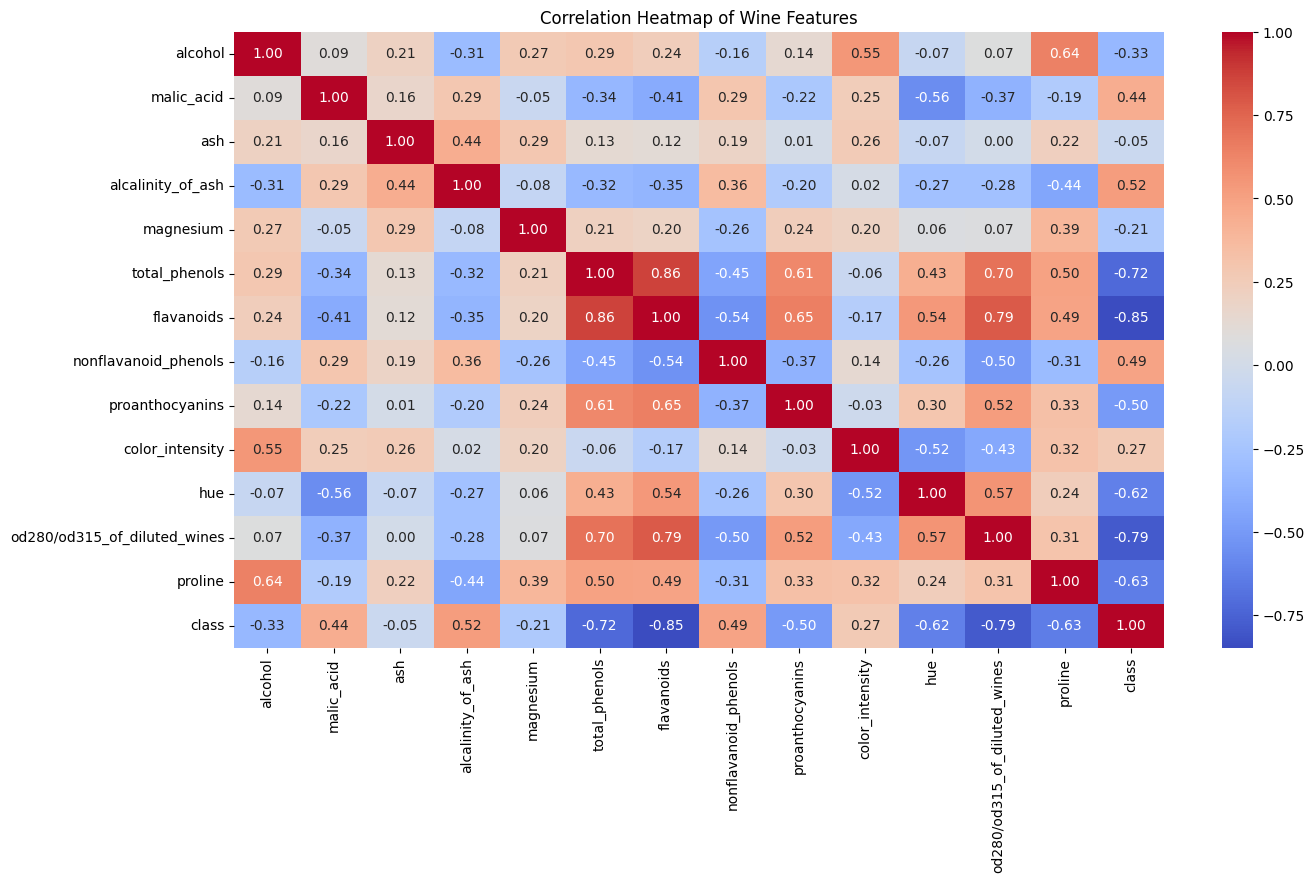

In [ ]:
# Постройте тепловую карту корреляций с помощью библиотеки seaborn
# 1. Создайте корреляционную матрицу с помощью функции df.corr(). Назовите DataFrame как df_wine_1_corr
#------------
df_wine_1_corr = df_wine_1.corr()
#-----------
# 2. Создайте объект "фигура" с размерами (12, 8)
#------------
plt.figure(figsize=(15, 8))
#-----------
# 3. Создайте тепловую карту с помощью функции sns.heatmap():
# - в качестве данных - df_wine_1_corr
# - подпишите значения внутри клеток
# - выберите цветовую карту - coolwarm
# - формат чисел - 2 знака после запятой (fmt = '.2f')
# - рядом с тепловой картой отобразите цветовую шкалу (cbar)
#------------
sns.heatmap(df_wine_1_corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
#-----------
# 4. Подпишите график как "Correlation Heatmap of Wine Features"
#------------
plt.title("Correlation Heatmap of Wine Features")
#-----------
plt.show()

### <font color='coral'>8. Гистограммы</font>

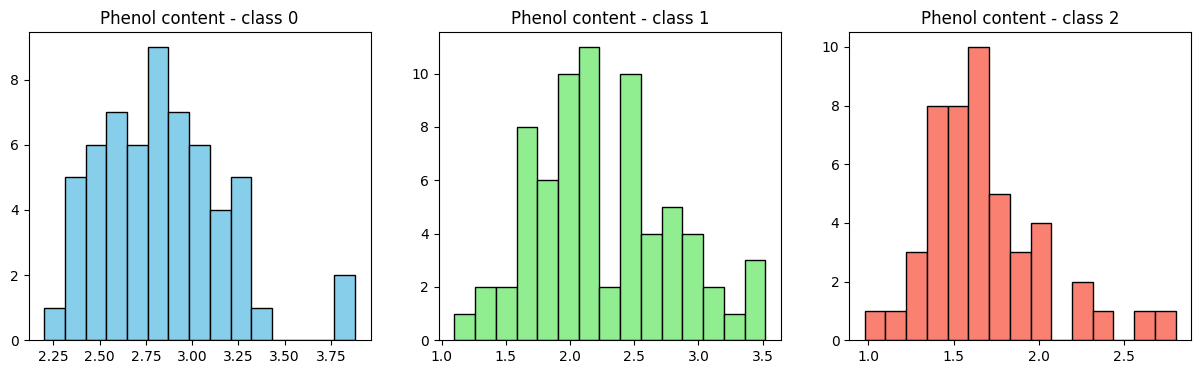

In [82]:
# Постройте гистограмму распределения содержания фенолов (total_phenols) в зависимости от класса вина с помощью matplotlib 
# 1. Создайте объект "фигура" размером (15, 4)
#------------
plt.figure(figsize=(15, 4))
#-----------
# 2. Расположите на этой фигуре 3 графика в ряд (используйте subplot)
#------------
plt.subplot(1, 3, 1)
#-----------
# 3. Нарисуйте гистограмму распределения (plt.hist) для класса 0 (на первом графике из 3-х)
# Параметры: x - столбец total_phenols из датафрейма df_wine_1, отфильтрованного только по классу 0
# количество столбцов (bins) = 15
# цвет - skyblue
# цвет границ столбцов - черный
#------------
plt.hist(df_wine_1[df_wine_1['class'] == 0]['total_phenols'], bins=15, color='skyblue', edgecolor='black')
#-----------
# 4. Подпишите гистограмму как "Phenol content - class 0"
#------------
plt.title("Phenol content - class 0")
#-----------
# 5. Нарисуйте гистограмму распределения для класса 1 (на втором графике из 3-х)
#------------
plt.subplot(1, 3, 2)
plt.hist(df_wine_1[df_wine_1['class'] == 1]['total_phenols'], bins=15, color='lightgreen', edgecolor='black')
#-----------
# 6. Подпишите гистограмму как "Phenol content - class 1"
#------------
plt.title("Phenol content - class 1")
#-----------
# 7. Нарисуйте гистограмму распределения для класса 2 (на третьем графике из 3-х)
#------------
plt.subplot(1, 3, 3)
plt.hist(df_wine_1[df_wine_1['class'] == 2]['total_phenols'], bins=15, color='salmon', edgecolor='black')
#-----------
# 6. Подпишите гистограмму как "Phenol content - class 2"
#------------
plt.title("Phenol content - class 2")
#-----------
plt.show()

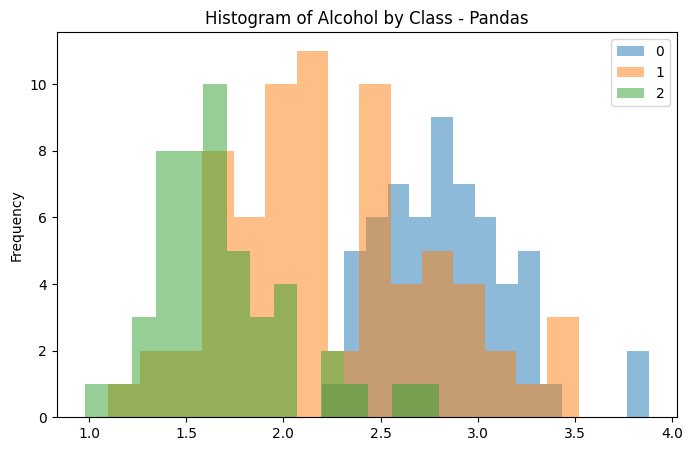

In [83]:
# Постройте гистограмму распределения содержания фенолов (total_phenols) в зависимости от класса вина с помощью pandas
# 1. Сгруппируйте данные по классу, не применяя никакой статистической функции, возьмите только столбец total_phenols
# Назовите получившийся объект Series - df_wine_1_grouped
#------------
df_wine_1_grouped = df_wine_1.groupby("class")["total_phenols"]
display(df_wine_1_grouped)
#-----------
# 2. Создайте объект "фигура" размером (8, 5)
#------------
plt.figure(figsize=(8, 5))
#-----------
# 3. На основании полученного Series постройте гистограмму со следующими параметрами:
# - количество столбцов (bins) - 15
# - прозрачность столбцов (alpha) - 0.5
# - показывать легенду
# - название графика - "Histogram of Alcohol by Class - Pandas"
#------------
df_wine_1_grouped.plot(kind='hist', bins=15, alpha=0.5, legend=True, title="Histogram of Alcohol by Class - Pandas")
#-----------
plt.show()

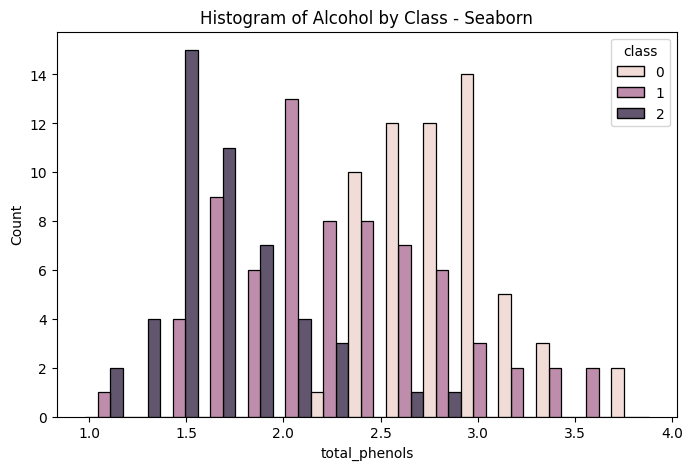

In [84]:
# Постройте гистограмму распределения содержания фенолов (total_phenols) в зависимости от класса вина с помощью seaborn
# 1. Создайте объект "фигура" размером (8, 5)
#------------
plt.figure(figsize=(8, 5))
#-----------
# 2. Постройте гистограмму sns.histplot с параметрами:
# - data = df_wine_1
# - по оси X - содержание фенолов (total_phenols)
# - разделение (hue) - по классу
# - количество столбцов (bins) - 15
# - расположение гистограмм относительно друг друга (multiple) - dodge
#------------
sns.histplot(data=df_wine_1, x='total_phenols', hue='class', bins=15, multiple='dodge')
#-----------
# 3. Подпишите гистограмму как "Histogram of Alcohol by Class - Seaborn"
#------------
plt.title("Histogram of Alcohol by Class - Seaborn")
#-----------
plt.show()

### <font color='coral'>9. Диаграмма рассеяния</font>

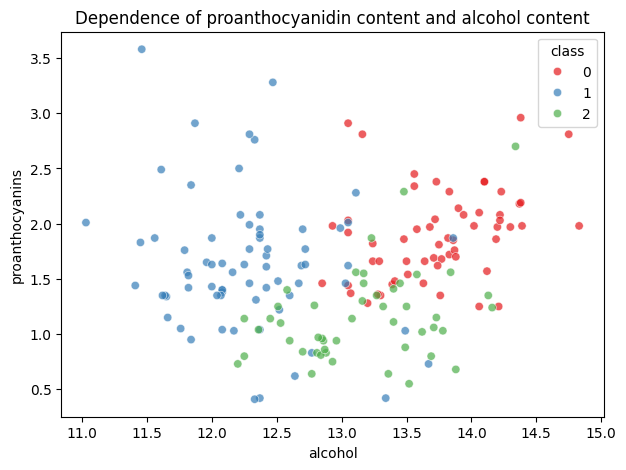

In [85]:
# Постройте диаграмму рассеяния для отображения 
# зависимости содержания проантоцианидинов (proanthocyanins) и содержания алкоголя (alcohol)
# Сделайте разделение по классам
# 1. Создайте объект "фигура" размером (7, 5)
#------------
plt.figure(figsize=(7, 5))
#-----------
# 2. С помощью sns.scatterplot постройте диаграмму рассеяния со следующими параметрами:
# - data = df_wine_1
# - по оси X - содержание алкоголя
# - по оси Y - содержание проантоцианидинов
# - разделение (hue) - по классам
# - цветовая палитра (palette) - Set1
# - прозрачность точек (alpha) - 0.7
#------------
sns.scatterplot(data=df_wine_1, x='alcohol', y='proanthocyanins', hue='class', palette='Set1', alpha=0.7)
#-----------
# 3. Подпишите диаграмму как "Dependence of proanthocyanidin content and alcohol content"
#------------
plt.title("Dependence of proanthocyanidin content and alcohol content")
#-----------
plt.show()